<a href="https://colab.research.google.com/github/davidogm/RNAP/blob/main/ComparativaRNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Qué problema estamos resolviendo (Adding Problem)

Entrada: una secuencia de longitud 𝑇. En cada instante 𝑡 tenemos dos features:

𝑥𝑡=[𝑥𝑡,𝑚𝑡]

𝑥𝑡 ∈ [0,1]: un número aleatorio.

𝑚𝑡 ∈ {0,1}: una “marca” que indica si ese paso temporal es relevante.

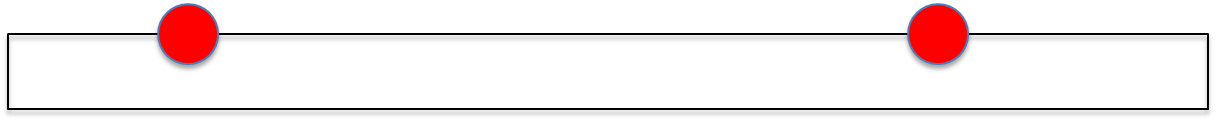

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(0)
tf.random.set_seed(0)

def train_val_test_split(X, y, train=0.7, val=0.15):
    n = len(X)
    i1 = int(train*n)
    i2 = int((train+val)*n)
    return (X[:i1], y[:i1]), (X[i1:i2], y[i1:i2]), (X[i2:], y[i2:])

def make_adding_problem(n_samples=60000, T=200):
    """
    Input per time step: [x_t, m_t]
      - x_t ~ Uniform(0,1)
      - m_t in {0,1}, with exactly two 1s per sequence (two marked positions)
    Target: y = sum of the two x_t at marked positions
    """
    # Generación de datos
    x = np.random.rand(n_samples, T, 1).astype(np.float32)
    m = np.zeros((n_samples, T, 1), dtype=np.float32)
    # x es un tensor (N, T, 1): números aleatorios en [0,1].
    # m es un tensor (N, T, 1): inicialmente todo cero.

    # choose two marker positions: one in first half, one in second half (forces long dependency)
    # Elegimos dos posiciones por secuencia, idx1: marca en primera mitad, idx2: marca en segunda mitad. Esto garantiza que están lejos (dependencia larga)
    idx1 = np.random.randint(0, T//2, size=n_samples)
    idx2 = np.random.randint(T//2, T, size=n_samples)

    # Marcamos esas posiciones:
    m[np.arange(n_samples), idx1, 0] = 1.0
    m[np.arange(n_samples), idx2, 0] = 1.0

    # Construimos la entrada concatenando ambas features:
    X = np.concatenate([x, m], axis=-1)  # shape (N, T, 2)  Así cada paso temporal tiene 2 números: [value, marker]

    # La etiqueta es exactamente la suma de los valores marcados:
    #Generamos la verdad fundamental (ground truth) directamente a partir de los datos: sumando los dos valores marcados.
    y = (x[np.arange(n_samples), idx1, 0] + x[np.arange(n_samples), idx2, 0]).astype(np.float32)
    return X, y

T = 200
X, y = make_adding_problem(n_samples=60000, T=T)
(X_train,y_train),(X_val,y_val),(X_test,y_test) = train_val_test_split(X,y)

def build_reg_model(rnn_layer):
    model = keras.Sequential([
        layers.Input(shape=(T, 2)),
        rnn_layer,
        layers.Dense(1)  # regression output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),  # clip helps SimpleRNN stability
        loss="mse"
    )
    return model

def train_and_report(layer, name, epochs=12):
    tf.random.set_seed(0)
    model = build_reg_model(layer)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val,y_val),
        epochs=epochs,
        batch_size=128,
        verbose=0
    )
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:10s} val_mse={hist.history['val_loss'][-1]:.4f}  test_mse={test_mse:.4f}")

train_and_report(layers.SimpleRNN(32, activation="tanh"), "SimpleRNN", epochs=12)
train_and_report(layers.GRU(32), "GRU", epochs=12)
train_and_report(layers.LSTM(32), "LSTM", epochs=12)

SimpleRNN  val_mse=0.1629  test_mse=0.1658
GRU        val_mse=0.0023  test_mse=0.0023
LSTM       val_mse=0.0608  test_mse=0.0597


Vamos a probar ejemplos con menos y más secuencias y pasos por secuencia, por ejemplo:


In [3]:
T = 100
X, y = make_adding_problem(n_samples=10000, T=T)
(X_train,y_train),(X_val,y_val),(X_test,y_test) = train_val_test_split(X,y)

def build_reg_model(rnn_layer):
    model = keras.Sequential([
        layers.Input(shape=(T, 2)),
        rnn_layer,
        layers.Dense(1)  # regression output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),  # clip helps SimpleRNN stability
        loss="mse"
    )
    return model

def train_and_report(layer, name, epochs=12):
    tf.random.set_seed(0)
    model = build_reg_model(layer)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val,y_val),
        epochs=epochs,
        batch_size=128,
        verbose=0
    )
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:10s} val_mse={hist.history['val_loss'][-1]:.4f}  test_mse={test_mse:.4f}")

train_and_report(layers.SimpleRNN(32, activation="tanh"), "SimpleRNN", epochs=12)
train_and_report(layers.GRU(32), "GRU", epochs=12)
train_and_report(layers.LSTM(32), "LSTM", epochs=12)



SimpleRNN  val_mse=0.1676  test_mse=0.1639
GRU        val_mse=0.1612  test_mse=0.1579
LSTM       val_mse=0.1659  test_mse=0.1632


In [4]:
T = 300
X, y = make_adding_problem(n_samples=100000, T=T)
(X_train,y_train),(X_val,y_val),(X_test,y_test) = train_val_test_split(X,y)

def build_reg_model(rnn_layer):
    model = keras.Sequential([
        layers.Input(shape=(T, 2)),
        rnn_layer,
        layers.Dense(1)  # regression output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),  # clip helps SimpleRNN stability
        loss="mse"
    )
    return model

def train_and_report(layer, name, epochs=12):
    tf.random.set_seed(0)
    model = build_reg_model(layer)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val,y_val),
        epochs=epochs,
        batch_size=128,
        verbose=0
    )
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:10s} val_mse={hist.history['val_loss'][-1]:.4f}  test_mse={test_mse:.4f}")

train_and_report(layers.SimpleRNN(32, activation="tanh"), "SimpleRNN", epochs=12)
train_and_report(layers.GRU(32), "GRU", epochs=12)
train_and_report(layers.LSTM(32), "LSTM", epochs=12)

SimpleRNN  val_mse=0.1671  test_mse=0.1653
GRU        val_mse=0.0010  test_mse=0.0010
LSTM       val_mse=0.0519  test_mse=0.0510
